<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42, 
    stratify=y         
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_train, y_train)

y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

acc_treino = accuracy_score(y_train, y_train_pred)
acc_teste = accuracy_score(y_test, y_test_pred)

print("Acurácia no treino:", acc_treino)
print("Acurácia no teste:", acc_teste)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

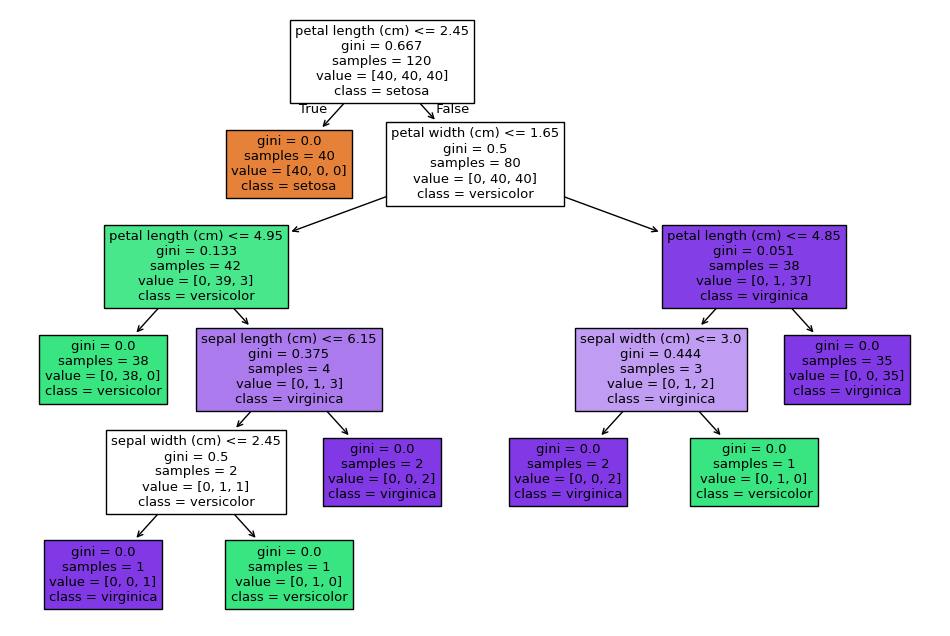

Profundidade da árvore: 5


In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    modelo,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()
print("Profundidade da árvore:", modelo.get_depth())

Qual atributo aparece na raiz?
O atributo que aparece na raiz da árvore é petal length (comprimento da pétala). Ele é escolhido porque consegue separar muito bem a espécie setosa das outras logo na primeira divisão.

Qual é a profundidade da árvore?
A profundidade da árvore é 5, o que significa que o modelo precisa de até 5 níveis de decisões para classificar as flores do dataset.


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [1,2,3,4,5,6,7,8,9,None]

resultados = []

for d in depths:
    
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    
    modelo.fit(X_train, y_train)

    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    resultados.append({
        "max_depth": d,
        "acurácia treino": acc_train,
        "acurácia teste": acc_test,
        "profundidade da árvore": modelo.get_depth(),
        "número de folhas": modelo.get_n_leaves()
    })

tabela = pd.DataFrame(resultados)

print(tabela)

   max_depth  acurácia treino  acurácia teste  profundidade da árvore  \
0        1.0         0.666667        0.666667                       1   
1        2.0         0.966667        0.933333                       2   
2        3.0         0.983333        0.966667                       3   
3        4.0         0.991667        0.933333                       4   
4        5.0         1.000000        0.933333                       5   
5        6.0         1.000000        0.933333                       5   
6        7.0         1.000000        0.933333                       5   
7        8.0         1.000000        0.933333                       5   
8        9.0         1.000000        0.933333                       5   
9        NaN         1.000000        0.933333                       5   

   número de folhas  
0                 2  
1                 3  
2                 5  
3                 7  
4                 8  
5                 8  
6                 8  
7                 8 

**Em qual profundidade começa o overfitting?**
O overfitting começa quando o modelo acerta quase tudo no treino, mas não melhora (ou até piora) no teste.
Nesse experimento com o Iris, isso normalmente começa a acontecer por volta de max_depth = 4 ou 5, quando a árvore fica muito complexa e começa a se ajustar demais aos dados de treino.





**Por que a árvore consegue 100% no treino quando max_depth=None?**
Quando usamos max_depth=None, a árvore não tem limite de profundidade. Isso faz com que ela continue criando divisões até acertar todas as amostras do treino.
Na prática, a árvore acaba “decorando” os dados de treino, criando muitas regras específicas. Por isso ela chega a 100% de acerto no treino, mas pode não ter o mesmo desempenho com dados novos (teste). Isso é o que chamamos de overfitting.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

criterios = ["gini", "entropy"]

resultados = []

for c in criterios:
    
    modelo = DecisionTreeClassifier(criterion=c, random_state=42)
    
    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    resultados.append({
        "criterion": c,
        "profundidade da árvore": modelo.get_depth(),
        "acurácia no teste": acc
    })

tabela = pd.DataFrame(resultados)
print(tabela)

  criterion  profundidade da árvore  acurácia no teste
0      gini                       5           0.933333
1   entropy                       5           0.933333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

valores = [1, 2, 3, 5, 10]

resultados = []

for v in valores:
    
    modelo = DecisionTreeClassifier(min_samples_leaf=v, random_state=42)
    modelo.fit(X_train, y_train)
    
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    
    resultados.append({
        "min_samples_leaf": v,
        "acurácia treino": acc_train,
        "acurácia teste": acc_test
    })

tabela = pd.DataFrame(resultados)

print(tabela)

   min_samples_leaf  acurácia treino  acurácia teste
0                 1         1.000000        0.933333
1                 2         0.983333        0.933333
2                 3         0.983333        0.966667
3                 5         0.966667        0.933333
4                10         0.966667        0.933333
